<a href="https://colab.research.google.com/github/masrik-dev/LangChain-Chat-with-Your-Data/blob/main/LangChain_Chat_with_Your_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LangChain: Chat with Your Data

## **Document Loading**

###**Retrieval augmented generation**
In retrieval augmented generation (**RAG**), an LLM retrieves contextual documents from an external dataset as part of its execution.

This is useful if we want to ask question about specific documents (e.g., our PDFs, a set of videos, etc).

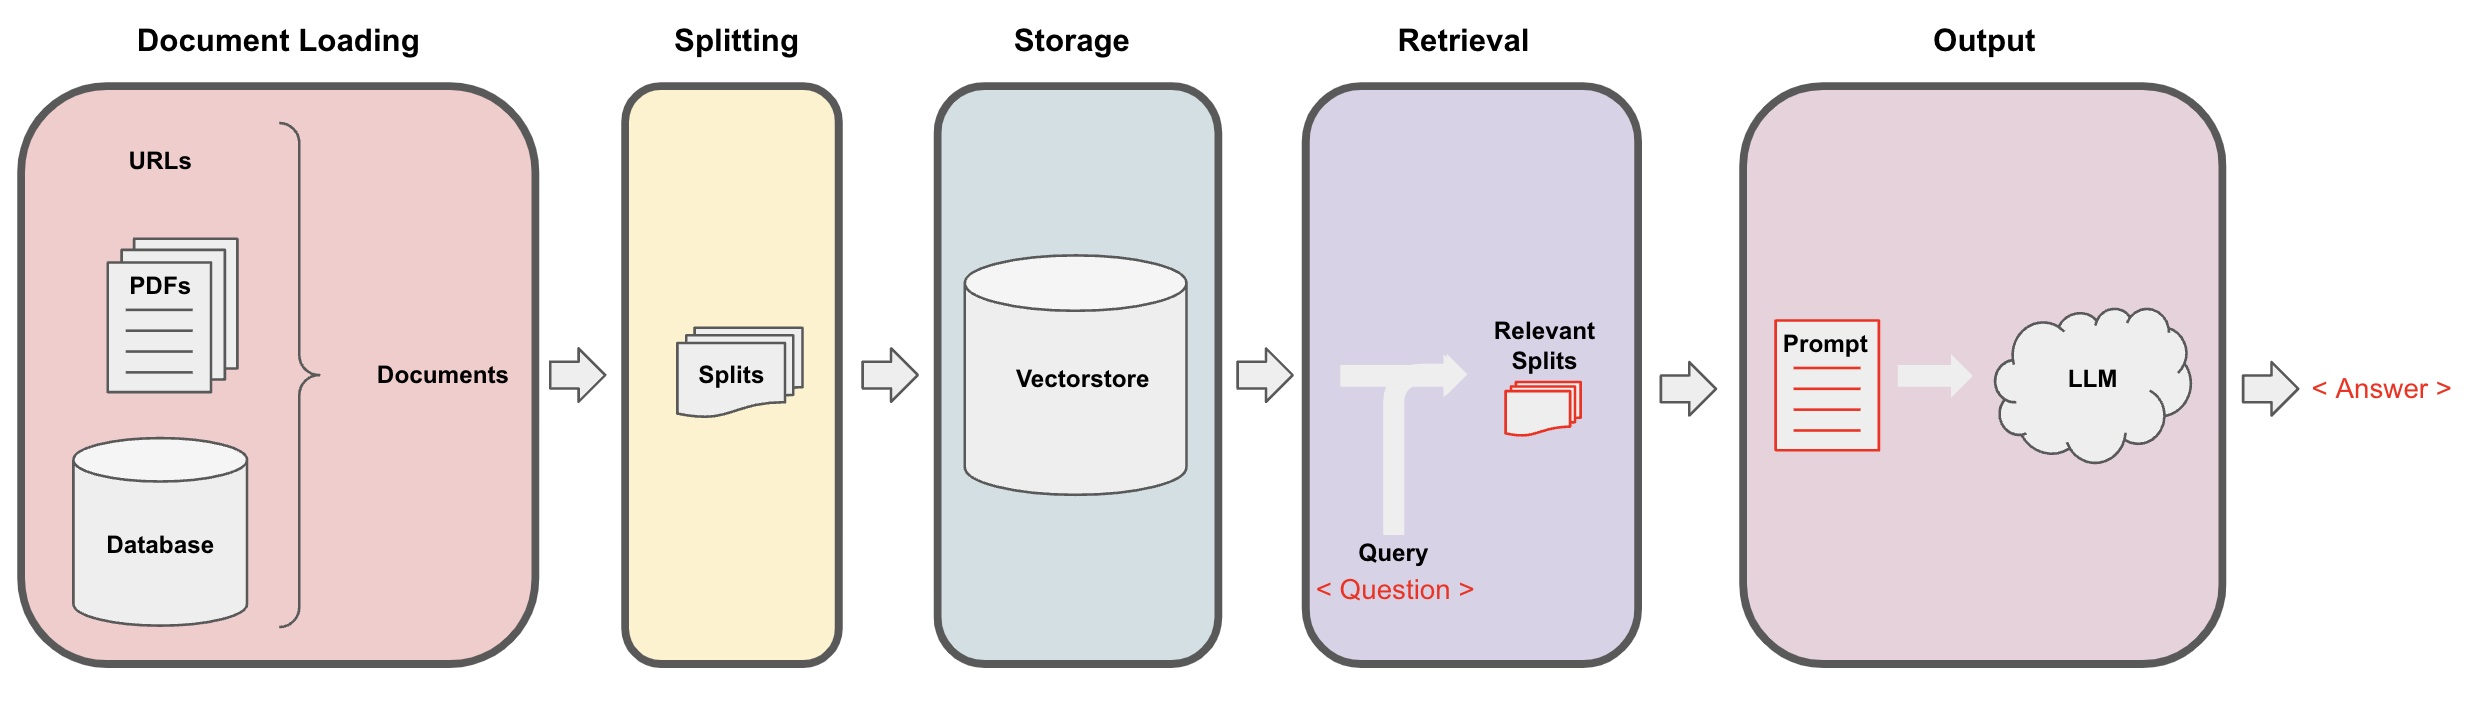

In [1]:
# First, Let's install Langchain
! pip install langchain

### API Key Setup & Environment Configuration

In [2]:
import os

try:
    # Try Colab Secrets first
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
except:
    # Fallback to local .env
    from dotenv import load_dotenv, find_dotenv
    load_dotenv(find_dotenv())

import openai
openai.api_key = os.environ["OPENAI_API_KEY"]

### **PDFs**
Let's load a PDF [transcript](https://see.stanford.edu/materials/aimlcs229/transcripts/MachineLearning-Lecture01.pdf) from Andrew Ng's famous CS229 course! These documemnts are the result of automated transcription so words and sentences are sometimes split unexpectedly.

In [3]:
!pip install pypdf

In [4]:
!pip install -U langchain langchain-community pypdf

In [5]:
#from langchain.document_loaders import PyPDFLoader
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("https://raw.githubusercontent.com/masrik-dev/LangChain-Chat-with-Your-Data/main/docs/cs229_lectures/MachineLearning-Lecture01.pdf")
pages = loader.load()

#### Extract each page as a `Document`.
A `Document` contains text(`page_content`) and `metadata`.

In [6]:
len(pages)

22

In [7]:
page = pages[0]

In [8]:
print(page.page_content[0:500])

MachineLearning-Lecture01  
Instructor (Andrew Ng): Okay. Good morning. Welcome to CS229, the machine 
learning class. So what I wanna do today is just spend a little time going over the logistics 
of the class, and then we'll start to talk a bit about machine learning.  
By way of introduction, my name's Andrew Ng and I'll be instructor for this class. And so 
I personally work in machine learning, and I've worked on it for about 15 years now, and 
I actually think that machine learning is the 


In [9]:
page.metadata

{'producer': 'Acrobat Distiller 8.1.0 (Windows)',
 'creator': 'PScript5.dll Version 5.2.2',
 'creationdate': '2008-07-11T11:25:23-07:00',
 'author': '',
 'moddate': '2008-07-11T11:25:23-07:00',
 'title': '',
 'source': 'https://raw.githubusercontent.com/masrik-dev/LangChain-Chat-with-Your-Data/main/docs/cs229_lectures/MachineLearning-Lecture01.pdf',
 'total_pages': 22,
 'page': 0,
 'page_label': '1'}

### **YouTube**

In [10]:
# from langchain_community.document_loaders.generic import GenericLoader
# from langchain_community.document_loaders.parsers import OpenAIWhisperParser
# from langchain_community.document_loaders.blob_loaders.youtube_audio import YoutubeAudioLoader
# from langchain_community.document_loaders.blob_loaders import FileSystemBlobLoader


In [11]:
# !pip install yt_dlp
# !pip install pydub

In [12]:
# url="https://www.youtube.com/watch?v=jGwO_UgTS7I"
# save_dir="docs/youtube/"
# loader = GenericLoader(
#     YoutubeAudioLoader([url],save_dir),  # fetch from youtube
#     # FileSystemBlobLoader(save_dir, glob="*.m4a"),   #fetch locally
#     OpenAIWhisperParser()
# )
# docs = loader.load()

In [13]:
# print(len(docs))
# #docs[0].page_content[0:500]

### **URLs**

In [14]:
from langchain_community.document_loaders import WebBaseLoader

loader = WebBaseLoader(
    "https://raw.githubusercontent.com/basecamp/handbook/master/titles-for-programmers.md"
)

In [15]:
docs = loader.load()

In [16]:
print(docs[0].page_content[:500])

# Titles for Programmers

## Programming Management

On Web, SIP, and Mobile programming teams, Lead Programmers (L4) and Principal Programmers (L5) act as tech leads to Junior - Senior Programmers (L1-3). All Principals report directly to our CTO. Tech leads are responsible for:
- Reviewing a report's substantial PRs before they're shipped.
- Having a kick-off conversation with a report on every substantial project.
- Reviewing a report's on-call work and handoff after every shift.
- Providing 


### **Notion**
We will follow steps from [here](https://docs.langchain.com/oss/python/langchain/overview) and take an example [Notion site](https://yolospace.notion.site/Blendle-s-Employee-Handbook-e31bff7da17346ee99f531087d8b133f).

In [17]:
!git clone https://github.com/masrik-dev/LangChain-Chat-with-Your-Data.git

fatal: destination path 'LangChain-Chat-with-Your-Data' already exists and is not an empty directory.


In [18]:
!ls LangChain-Chat-with-Your-Data/docs/

cs229_lectures	Notion


In [19]:
!pip install unstructured markdown

In [20]:
# from langchain_community.document_loaders import NotionDirectoryLoader

# loader = NotionDirectoryLoader(
#     "LangChain-Chat-with-Your-Data/docs/Notion_DB"
# )

# docs = loader.load()
# print(len(docs))

In [21]:
from langchain_community.document_loaders import DirectoryLoader

loader = DirectoryLoader(
    "LangChain-Chat-with-Your-Data/docs/Notion",
    glob="**/*.md"
)

docs = loader.load()

In [22]:
print(len(docs))
print(docs[0].page_content[:300])

52
Blendle's Employee Handbook

This is a living document with everything we've learned working with people while running a startup. And, of course, we continue to learn. Therefore it's a document that will continue to change.

Everything related to working at Blendle and the people of Blendle, made pu


## **Document Splitting**

In [23]:
!pip install langchain-text-splitters

In [24]:
from langchain_text_splitters import RecursiveCharacterTextSplitter, CharacterTextSplitter

In [25]:
chunk_size = 26
chunk_overlap = 4

In [26]:
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap
)
c_splitter = CharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap
)

Why doesn't this split the string below?

In [27]:
text1 = 'abcdefghijklmnopqrstuvwxyz'

In [28]:
r_splitter.split_text(text1)

['abcdefghijklmnopqrstuvwxyz']

In [29]:
text2 = 'avadacavraozimandiesargomosopotemia'

In [30]:
r_splitter.split_text(text2)

['avadacavraozimandiesargomo', 'gomosopotemia']

Ok, this splits the string but we have an overlap specified as 5, but it looks like 3... (try an even number)

In [31]:
text3 = "l a d i o d i d e t h i n f i l m p e r o v s k i t e s o l a r"

In [32]:
r_splitter.split_text(text3)

['l a d i o d i d e t h i n',
 'i n f i l m p e r o v s k',
 's k i t e s o l a r']

In [33]:
c_splitter.split_text(text3)

['l a d i o d i d e t h i n f i l m p e r o v s k i t e s o l a r']

In [34]:
c_splitter = CharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap,
    separator = " "
)
c_splitter.split_text(text3)

['l a d i o d i d e t h i n',
 'i n f i l m p e r o v s k',
 's k i t e s o l a r']

### **Recursive splitting details**
`RecursiveCharacterTextSplitter` is recommended for generic text.

In [35]:
some_text = """When writing documents, writers will use document structure to group content. \
This can convey to the reader, which idea's are related. For example, closely related ideas \
are in sentances. Similar ideas are in paragraphs. Paragraphs form a document. \n\n  \
Paragraphs are often delimited with a carriage return or two carriage returns. \
Carriage returns are the "backslash n" you see embedded in this string. \
Sentences have a period at the end, but also, have a space.\
and words are separated by space."""

In [36]:
len(some_text)

496

In [37]:
c_splitter = CharacterTextSplitter(
    chunk_size=450,
    chunk_overlap=0,
    separator = " "
)
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=450,
    chunk_overlap=0,
    separators=["\n\n", "\n", " ", ""]
)

In [38]:
c_splitter.split_text(some_text)

['When writing documents, writers will use document structure to group content. This can convey to the reader, which idea\'s are related. For example, closely related ideas are in sentances. Similar ideas are in paragraphs. Paragraphs form a document. \n\n Paragraphs are often delimited with a carriage return or two carriage returns. Carriage returns are the "backslash n" you see embedded in this string. Sentences have a period at the end, but also,',
 'have a space.and words are separated by space.']

In [39]:
r_splitter.split_text(some_text)

["When writing documents, writers will use document structure to group content. This can convey to the reader, which idea's are related. For example, closely related ideas are in sentances. Similar ideas are in paragraphs. Paragraphs form a document.",
 'Paragraphs are often delimited with a carriage return or two carriage returns. Carriage returns are the "backslash n" you see embedded in this string. Sentences have a period at the end, but also, have a space.and words are separated by space.']

Let's reduce the chunk size a bit and add a period to our separators:

In [40]:
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=150,
    chunk_overlap=0,
    separators=["\n\n", "\n", "\. ", " ", ""]
)
r_splitter.split_text(some_text)

<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_20418/158012430.py:4: SyntaxWarning: invalid escape sequence '\.'
  separators=["\n\n", "\n", "\. ", " ", ""]


["When writing documents, writers will use document structure to group content. This can convey to the reader, which idea's are related. For example,",
 'closely related ideas are in sentances. Similar ideas are in paragraphs. Paragraphs form a document.',
 'Paragraphs are often delimited with a carriage return or two carriage returns. Carriage returns are the "backslash n" you see embedded in this',
 'string. Sentences have a period at the end, but also, have a space.and words are separated by space.']

In [41]:
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=150,
    chunk_overlap=0,
    separators=["\n\n", "\n", "(?<=\. )", " ", ""]
)
r_splitter.split_text(some_text)

<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_20418/2945222903.py:4: SyntaxWarning: invalid escape sequence '\.'
  separators=["\n\n", "\n", "(?<=\. )", " ", ""]


["When writing documents, writers will use document structure to group content. This can convey to the reader, which idea's are related. For example,",
 'closely related ideas are in sentances. Similar ideas are in paragraphs. Paragraphs form a document.',
 'Paragraphs are often delimited with a carriage return or two carriage returns. Carriage returns are the "backslash n" you see embedded in this',
 'string. Sentences have a period at the end, but also, have a space.and words are separated by space.']

In [42]:
from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader("https://raw.githubusercontent.com/masrik-dev/LangChain-Chat-with-Your-Data/main/docs/cs229_lectures/MachineLearning-Lecture01.pdf")
pages = loader.load()

In [43]:
from langchain_text_splitters import CharacterTextSplitter
text_splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size=1000,
    chunk_overlap=150,
    length_function=len
)

In [44]:
docs = text_splitter.split_documents(pages)

In [45]:
len(docs)

78

In [46]:
len(pages)

22

In [47]:
from langchain_community.document_loaders import DirectoryLoader

loader = DirectoryLoader(
    "LangChain-Chat-with-Your-Data/docs/Notion",
    glob="**/*.md"
)

notion_db = loader.load()

In [48]:
docs = text_splitter.split_documents(notion_db)

In [49]:
len(notion_db)

52

In [50]:
len(docs)

299

### **Token splitting**
We can also split on token count explicity, if we want.
This can be useful because LLMs often have context windows designated in tokens.
Tokens are often ~4 characters.

In [51]:
from langchain_text_splitters import TokenTextSplitter

In [52]:
text_splitter = TokenTextSplitter(chunk_size=1, chunk_overlap=0)

In [53]:
text1 = "for the wind to carry some words"

In [54]:
text_splitter.split_text(text1)

['for', ' the', ' wind', ' to', ' carry', ' some', ' words']

In [55]:
text_splitter = TokenTextSplitter(chunk_size=10, chunk_overlap=0)

In [56]:
docs = text_splitter.split_documents(pages)

In [57]:
docs[0]

Document(metadata={'producer': 'Acrobat Distiller 8.1.0 (Windows)', 'creator': 'PScript5.dll Version 5.2.2', 'creationdate': '2008-07-11T11:25:23-07:00', 'author': '', 'moddate': '2008-07-11T11:25:23-07:00', 'title': '', 'source': 'https://raw.githubusercontent.com/masrik-dev/LangChain-Chat-with-Your-Data/main/docs/cs229_lectures/MachineLearning-Lecture01.pdf', 'total_pages': 22, 'page': 0, 'page_label': '1'}, page_content='MachineLearning-Lecture01  \n')

In [58]:
pages[0].metadata

{'producer': 'Acrobat Distiller 8.1.0 (Windows)',
 'creator': 'PScript5.dll Version 5.2.2',
 'creationdate': '2008-07-11T11:25:23-07:00',
 'author': '',
 'moddate': '2008-07-11T11:25:23-07:00',
 'title': '',
 'source': 'https://raw.githubusercontent.com/masrik-dev/LangChain-Chat-with-Your-Data/main/docs/cs229_lectures/MachineLearning-Lecture01.pdf',
 'total_pages': 22,
 'page': 0,
 'page_label': '1'}

### **Context aware splitting**
Chunking aims to keep text with common context together.

A text splitting often uses sentences or other delimiters to keep related text together but many documents (such as Markdown) have structure (headers) that can be explicitly used in splitting.

We can use `MarkdownHeaderTextSplitter` to preserve header metadata in our chunks.

In [59]:
from langchain_community.document_loaders import NotionDirectoryLoader
from langchain_text_splitters import MarkdownHeaderTextSplitter

In [60]:
markdown_document = """# Title\n\n \
## Chapter 1\n\n \
Hi this is Jhon\n\n Hi this is Miranda\n\n \
### Section \n\n \
Hi this is Linda \n\n
## Chapter 2\n\n \
Hi this is Kevin"""

In [61]:
headers_to_split_on = [
    ("#", "Header 1"),
    ("##", "Header 2"),
    ("###", "Header 3"),
]

In [62]:
markdown_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=headers_to_split_on
)
md_header_splits = markdown_splitter.split_text(markdown_document)

In [63]:
md_header_splits[0]

Document(metadata={'Header 1': 'Title', 'Header 2': 'Chapter 1'}, page_content='Hi this is Jhon  \nHi this is Miranda')

In [64]:
md_header_splits[1]

Document(metadata={'Header 1': 'Title', 'Header 2': 'Chapter 1', 'Header 3': 'Section'}, page_content='Hi this is Linda')

Now try it on real Markdown file.

In [65]:
loader = DirectoryLoader(
    "LangChain-Chat-with-Your-Data/docs/Notion",
    glob="**/*.md"
)

docs = loader.load()
txt = ' '.join([d.page_content for d in docs])

In [66]:
txt[:100]

"Blendle's Employee Handbook\n\nThis is a living document with everything we've learned working with pe"

In [67]:
headers_to_split_on = [
    ("#", "Header 1"),
    ("##", "Header 2"),
]
markdown_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=headers_to_split_on
)

In [68]:
md_header_splits = markdown_splitter.split_text(txt)

In [69]:
md_header_splits[0]

Document(metadata={}, page_content='Blendle\'s Employee Handbook  \nThis is a living document with everything we\'ve learned working with people while running a startup. And, of course, we continue to learn. Therefore it\'s a document that will continue to change.  \nEverything related to working at Blendle and the people of Blendle, made public.  \nThese are the lessons from three years of working with the people of Blendle. It contains everything from how our leaders lead to how we increase salaries, from how we hire and fire to how we think people should give each other feedback — and much more.  \nWe\'ve made this document public because we want to learn from you. We\'re very much interested in your feedback (including weeding out typo\'s and Dunglish ;)). Email us at hr@blendle.com. If you\'re starting your own company or if you\'re curious as to how we do things at Blendle, we hope that our employee handbook inspires you.  \nIf you want to work at Blendle you can check our job ad